In [1]:
# ============ 셀 1: 설정 ============
import os, json, time, math, random, glob, shutil, copy
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.nn.attention import sdpa_kernel, SDPBackend

assert torch.cuda.is_available(), "GPU가 꺼져 있어요. Settings → Accelerator → GPU T4 로 바꾸세요."
DEV = 'cuda'
torch.backends.cuda.matmul.allow_tf32 = True

OUT  = '/kaggle/working/exp_llm_adamw'   # 결과 (작은 파일 + 모델)
DATA = '/tmp/llm_data'                   # 토큰화한 데이터
os.makedirs(OUT, exist_ok=True); os.makedirs(DATA, exist_ok=True)

CFG = dict(
    seed=0, ctx=256, vocab=50304,                     # GPT-2 토크나이저(50257) → 64의 배수로 패딩
    d_model=512, n_layer=6, n_head=8,
    # 사전학습 (BabyLM, AdamW, WSD)
    pre_epochs=10, pre_bs=32, pre_wd=0.1, warmup_frac=0.02, decay_frac=0.2, pre_rho=0.05,
    sweep_lrs=[3e-4, 1e-3, 3e-3], sweep_frac=0.25, grad_clip=1.0,
    # 파인튜닝 (파이썬 코드, SAM 없음)
    ft_steps=1000, ft_bs=32, ft_wd=0.1, ft_warmup=50, ft_lr_div=[10, 3], ft_seeds=[0, 1, 2], ft_eval_every=100,
    code_files=10000, code_max_chars=20000,
    # 평가
    eval_seqs=400, eval_bs=32, hvp_iters=20,
)
json.dump(CFG, open(f'{OUT}/config.json', 'w'), indent=2)

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

print('GPU :', torch.cuda.get_device_name(0), '| torch', torch.__version__)
for d in ['/kaggle/working', '/tmp']:
    print(f'{d} 여유 공간: {shutil.disk_usage(d).free/1e9:.1f} GB')

GPU : Tesla T4 | torch 2.10.0+cu128
/kaggle/working 여유 공간: 20.9 GB
/tmp 여유 공간: 1201.7 GB


In [2]:
# ============ 셀 2: BabyLM + 파이썬 코드 다운로드, 토큰화 (한 번만) ============
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained('gpt2'); tok.model_max_length = int(1e9)
EOS = tok.eos_token_id

def encode_texts(texts, bs=256):
    parts = []
    for i in range(0, len(texts), bs):
        for ids in tok(texts[i:i + bs])['input_ids']:
            parts.append(np.array(ids + [EOS], dtype=np.uint16))
    return np.concatenate(parts)

def chunk_lines(text, n=200):
    lines = text.split('\n')
    return ['\n'.join(lines[i:i + n]) for i in range(0, len(lines), n)]

# ---------- BabyLM ----------
if os.path.exists(f'{DATA}/babylm_val.npy'):
    print('BabyLM 토큰 파일이 이미 있음 → 건너뜀')
else:
    try:
        from huggingface_hub import snapshot_download
        root = snapshot_download('cambridge-climb/BabyLM', repo_type='dataset', allow_patterns=['10M/*', 'dev/*'])
        tr_files = sorted(f for f in glob.glob(f'{root}/10M/*') if os.path.isfile(f))
        dv_files = sorted(f for f in glob.glob(f'{root}/dev/*') if os.path.isfile(f))
        assert tr_files and dv_files, '파일 없음'
        tr_texts, dv_texts = [], []
        for f in tr_files: tr_texts += chunk_lines(open(f, encoding='utf-8', errors='ignore').read())
        for f in dv_files: dv_texts += chunk_lines(open(f, encoding='utf-8', errors='ignore').read()[:500_000])
        src = f'cambridge-climb/BabyLM (2023) | train 파일 {len(tr_files)}개, dev 파일 {len(dv_files)}개'
    except Exception as e:
        print('2023판 다운로드 실패 → 2026판으로 대체:', repr(e)[:200])
        from datasets import load_dataset
        ds = load_dataset('BabyLM-community/BabyLM-2026-Strict-Small', split='train')
        col = [c for c, t in ds.features.items() if getattr(t, 'dtype', None) == 'string'][0]
        lines = [t for t in ds[col] if t and t.strip()]
        idx = np.random.RandomState(0).permutation(len(lines)); nv = len(lines) // 20
        dv_lines = [lines[i] for i in idx[:nv]]; tr_lines = [lines[i] for i in idx[nv:]]
        tr_texts = ['\n'.join(tr_lines[i:i + 200]) for i in range(0, len(tr_lines), 200)]
        dv_texts = ['\n'.join(dv_lines[i:i + 200]) for i in range(0, len(dv_lines), 200)]
        src = 'BabyLM-community/BabyLM-2026-Strict-Small (5%를 검증용으로 분리)'
    print('BabyLM 출처:', src, flush=True)
    tr = encode_texts(tr_texts); dv = encode_texts(dv_texts)
    np.save(f'{DATA}/babylm_train.npy', tr); np.save(f'{DATA}/babylm_val.npy', dv)
    print(f'BabyLM 토큰: train {len(tr)/1e6:.1f}M, val {len(dv)/1e6:.1f}M')
    json.dump(dict(babylm_source=src), open(f'{OUT}/data_source_babylm.json', 'w'))

# ---------- 파이썬 코드 ----------
if os.path.exists(f'{DATA}/code_val.npy'):
    print('코드 토큰 파일이 이미 있음 → 건너뜀')
else:
    from datasets import load_dataset
    try:
        ds = load_dataset('bigcode/the-stack-smol', data_dir='data/python', split='train')
        src = 'bigcode/the-stack-smol (python)'
    except Exception as e:
        print('the-stack-smol 실패(약관 동의 필요 등) → codeparrot으로 대체:', repr(e)[:200])
        ds = load_dataset('codeparrot/codeparrot-clean-valid', split='train')
        src = 'codeparrot/codeparrot-clean-valid'
    n = min(CFG['code_files'], len(ds))
    ds = ds.shuffle(seed=0).select(range(n))
    files = [c[:CFG['code_max_chars']] for c in ds['content']]
    nv = n // 10
    cv = encode_texts(files[:nv]); ct = encode_texts(files[nv:])
    np.save(f'{DATA}/code_train.npy', ct); np.save(f'{DATA}/code_val.npy', cv)
    print(f'코드 출처: {src} | 파일 {n}개 | 토큰: train {len(ct)/1e6:.1f}M, val {len(cv)/1e6:.1f}M')
    json.dump(dict(code_source=src, files=n), open(f'{OUT}/data_source_code.json', 'w'))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

README.md:   0%|          | 0.00/401 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


file-000000000054.json.gz:   0%|          | 0.00/142M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61373 [00:00<?, ? examples/s]

코드 출처: codeparrot/codeparrot-clean-valid | 파일 10000개 | 토큰: train 26.9M, val 3.0M


In [3]:
# ============ 셀 3: 공통 도구 (데이터 스트림, 모델, SAM, 평가) ============
def load_tokens(name):
    return torch.from_numpy(np.load(f'{DATA}/{name}.npy').astype(np.int64)).to(DEV)

TR_BABY, VA_BABY = load_tokens('babylm_train'), load_tokens('babylm_val')
TR_CODE, VA_CODE = load_tokens('code_train'), load_tokens('code_val')

class Stream:
    """토큰 배열을 길이 ctx+1 조각으로 나누고, (seed, epoch)마다 같은 순서로 섞어서 배치를 준다."""
    def __init__(self, tokens, bs, ctx=CFG['ctx']):
        n = (len(tokens) - 1) // ctx
        self.chunks = tokens[:n * ctx + 1].unfold(0, ctx + 1, ctx)
        self.n, self.bs, self.spe = n, bs, n // bs
        self._key = None
    def batch(self, step, seed):
        ep, i = divmod(step, self.spe)
        if self._key != (seed, ep):
            g = torch.Generator().manual_seed(seed * 100003 + ep)
            self._perm = torch.randperm(self.n, generator=g).to(DEV); self._key = (seed, ep)
        b = self.chunks[self._perm[i * self.bs:(i + 1) * self.bs]]
        return b[:, :-1], b[:, 1:]

def make_eval(tokens, n, seed, ctx=CFG['ctx']):
    starts = np.random.RandomState(seed).randint(0, len(tokens) - ctx - 1, size=n)
    idx = torch.from_numpy(starts).to(DEV)[:, None] + torch.arange(ctx + 1, device=DEV)
    b = tokens[idx]
    return b[:, :-1], b[:, 1:]

EV_BABY = make_eval(VA_BABY, CFG['eval_seqs'], seed=11)
EV_CODE = make_eval(VA_CODE, CFG['eval_seqs'], seed=12)

class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.h = h
        self.ln1 = nn.LayerNorm(d); self.qkv = nn.Linear(d, 3 * d); self.proj = nn.Linear(d, d)
        self.ln2 = nn.LayerNorm(d); self.fc = nn.Linear(d, 4 * d); self.fc2 = nn.Linear(4 * d, d)
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(self.ln1(x)).split(C, dim=2)
        q, k, v = [t.view(B, T, self.h, C // self.h).transpose(1, 2) for t in (q, k, v)]
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x = x + self.proj(y.transpose(1, 2).contiguous().view(B, T, C))
        return x + self.fc2(F.gelu(self.fc(self.ln2(x))))

class GPT(nn.Module):
    def __init__(self, V=CFG['vocab'], d=CFG['d_model'], L=CFG['n_layer'], h=CFG['n_head'], T=CFG['ctx']):
        super().__init__()
        self.wte = nn.Embedding(V, d); self.wpe = nn.Embedding(T, d)
        self.blocks = nn.ModuleList([Block(d, h) for _ in range(L)])
        self.lnf = nn.LayerNorm(d)
        for n, p in self.named_parameters():
            if p.ndim >= 2:
                std = 0.02 / math.sqrt(2 * L) if n.endswith(('proj.weight', 'fc2.weight')) else 0.02
                nn.init.normal_(p, 0.0, std)
            elif n.endswith('bias'):
                nn.init.zeros_(p)
    def forward(self, idx, targets):
        x = self.wte(idx) + self.wpe(torch.arange(idx.shape[1], device=idx.device))
        for b in self.blocks:
            x = b(x)
        logits = F.linear(self.lnf(x), self.wte.weight)          # 입력 임베딩과 출력층 공유
        return F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))

def make_model():
    return GPT().to(DEV)

def make_opt(model, lr, wd):
    decay = [p for p in model.parameters() if p.ndim >= 2]
    no_decay = [p for p in model.parameters() if p.ndim < 2]
    opt = torch.optim.AdamW([{'params': decay, 'weight_decay': wd},
                             {'params': no_decay, 'weight_decay': 0.0}], lr=lr, betas=(0.9, 0.95), eps=1e-8)
    for g in opt.param_groups: g['base_lr'] = lr
    return opt

def wsd_fn(total, warm, decay_start):
    def f(s):
        if s < warm: return (s + 1) / warm
        if s < decay_start: return 1.0
        return max(0.0, (total - s) / (total - decay_start))
    return f

def cos_fn(total, warm):
    def f(s):
        if s < warm: return (s + 1) / warm
        return 0.5 * (1 + math.cos(math.pi * (s - warm) / max(1, total - warm)))
    return f

def train_step(model, opt, scaler, x, y, rho):
    """SAM Overlay: rho>0이면 교란점의 그래디언트로 바꿔치기만 하고, 갱신은 AdamW가 그대로 수행."""
    with torch.autocast('cuda', dtype=torch.float16):
        loss = model(x, y)
    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    used = 0
    if rho > 0:
        params = [p for p in model.parameters() if p.grad is not None]
        gn = torch.norm(torch.stack([p.grad.norm(2) for p in params]), 2)   # 스케일된 그래디언트: 방향만 쓰므로 상쇄
        if torch.isfinite(gn).item() and gn.item() > 0:
            with torch.no_grad():
                backup = [p.detach().clone() for p in params]
                k = rho / (gn + 1e-12)
                for p in params: p.add_(p.grad * k)
            opt.zero_grad(set_to_none=True)
            with torch.autocast('cuda', dtype=torch.float16):
                loss2 = model(x, y)
            scaler.scale(loss2).backward()
            with torch.no_grad():
                for p, b in zip(params, backup): p.copy_(b)     # 빼지 않고 복사로 원위치
            used = 1
    scaler.unscale_(opt)
    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
    scaler.step(opt); scaler.update()
    return loss.detach(), used

@torch.no_grad()
def eval_loss(model, ev):
    model.eval(); X, Y = ev; tot = 0.0; bs = CFG['eval_bs']
    for i in range(0, len(X), bs):
        with torch.autocast('cuda', dtype=torch.float16):
            tot += model(X[i:i + bs], Y[i:i + bs]).float().item() * len(X[i:i + bs])
    model.train()
    return tot / len(X)

def train_steps(model, opt, scaler, stream, s_from, s_to, lr_fn, rho, seed, log, eval_every, tag, total):
    model.train(); t0 = time.time(); acc = torch.zeros((), device=DEV); cnt = 0; used = 0
    for s in range(s_from, s_to):
        f = lr_fn(s)
        for g in opt.param_groups: g['lr'] = g['base_lr'] * f
        x, y = stream.batch(s, seed)
        l, u = train_step(model, opt, scaler, x, y, rho)
        acc += l; cnt += 1; used += u
        if (s + 1) % eval_every == 0 or s + 1 == s_to:
            vl = eval_loss(model, EV_BABY); tl = (acc / cnt).item(); dt = time.time() - t0
            log.append(dict(step=s + 1, train_loss=tl, val_loss=vl, sam_steps=used, sec=dt))
            print(f'[{tag}] step {s+1}/{total}  train {tl:.3f}  BabyLM val {vl:.3f} (ppl {math.exp(min(vl, 20)):.1f})  '
                  f'SAM {used}/{cnt}  {dt/cnt:.3f}s/step', flush=True)
            acc.zero_(); cnt = 0; used = 0; t0 = time.time()

def delta_rel(sd_a, sd_b):
    num = den = 0.0
    for k, v in sd_a.items():
        if not v.is_floating_point(): continue
        num += (sd_b[k].float() - v.float()).pow(2).sum().item(); den += v.float().pow(2).sum().item()
    return math.sqrt(num / den)

def sam_gap(model, batches, rho):
    model.eval(); gaps = []; params = list(model.parameters())
    for x, y in batches:
        model.zero_grad(set_to_none=True)
        loss = model(x, y); loss.backward()
        gn = torch.norm(torch.stack([p.grad.norm() for p in params]))
        with torch.no_grad():
            backup = [p.detach().clone() for p in params]
            for p in params: p.add_(p.grad * (rho / (gn + 1e-12)))
            l2 = model(x, y)
            for p, b in zip(params, backup): p.copy_(b)
        gaps.append((l2 - loss).item())
    model.zero_grad(set_to_none=True)
    return float(np.mean(gaps))

def lambda_max(model, batch, iters):
    model.eval(); x, y = batch; params = list(model.parameters())
    with sdpa_kernel(SDPBackend.MATH):                     # 2차 미분이 되는 어텐션 경로
        loss = model(x, y)
        grads = torch.autograd.grad(loss, params, create_graph=True)
        v = [torch.randn_like(p) for p in params]
        nrm = torch.sqrt(sum((a * a).sum() for a in v)); v = [a / nrm for a in v]
        lam = 0.0
        for _ in range(iters):
            Hv = torch.autograd.grad(grads, params, grad_outputs=v, retain_graph=True)
            lam = sum((h * a).sum() for h, a in zip(Hv, v)).item()
            nrm = torch.sqrt(sum((h * h).sum() for h in Hv)); v = [h.detach() / nrm for h in Hv]
    del grads
    return lam

tr_stream = Stream(TR_BABY, CFG['pre_bs'])
TOTAL = CFG['pre_epochs'] * tr_stream.spe
print(f'모델 파라미터 {sum(p.numel() for p in make_model().parameters())/1e6:.1f}M | '
      f'BabyLM epoch당 {tr_stream.spe} step, 사전학습 전체 {TOTAL} step')

모델 파라미터 44.8M | BabyLM epoch당 1914 step, 사전학습 전체 19140 step


In [4]:
# ============ 셀 4: 0단계 — AdamW 학습률 스윕 (전체의 25% 길이, 자체 WSD) ============
sweep_path = f'{OUT}/lr_sweep.json'
SWEEP = json.load(open(sweep_path)) if os.path.exists(sweep_path) else {}
S_sw = int(TOTAL * CFG['sweep_frac'])
for lr in CFG['sweep_lrs']:
    key = f'{lr:g}'
    if key in SWEEP:
        print(f'lr={key} 이미 있음 → 건너뜀'); continue
    print(f'\n=== 스윕 lr={key} ({S_sw} step) ===')
    seed_all(CFG['seed'])
    model = make_model(); opt = make_opt(model, lr, CFG['pre_wd']); scaler = torch.amp.GradScaler('cuda')
    lr_fn = wsd_fn(S_sw, max(1, int(S_sw * CFG['warmup_frac'])), int(S_sw * (1 - CFG['decay_frac'])))
    log = []
    train_steps(model, opt, scaler, tr_stream, 0, S_sw, lr_fn, 0.0, CFG['seed'], log, max(1, S_sw // 5), f'sweep {key}', S_sw)
    vl = eval_loss(model, EV_BABY)
    SWEEP[key] = dict(lr=lr, val_loss=vl if math.isfinite(vl) else float('inf'), log=log)
    json.dump(SWEEP, open(sweep_path, 'w'), indent=1)
    del model, opt; torch.cuda.empty_cache()

print('\n===== 스윕 결과 =====')
for k, r in SWEEP.items():
    print(f'  lr={k}: BabyLM val loss {r["val_loss"]:.4f}')
BEST_LR = min(SWEEP.values(), key=lambda r: r['val_loss'])['lr']
print(f'→ 선택된 학습률: {BEST_LR:g}')
if BEST_LR in (min(CFG['sweep_lrs']), max(CFG['sweep_lrs'])):
    print('※ 최적값이 스윕 범위 끝에 있음. 결과 볼 때 참고할 것.')


=== 스윕 lr=0.0003 (4785 step) ===
[sweep 0.0003] step 957/4785  train 4.605  BabyLM val 4.023 (ppl 55.8)  SAM 0/957  0.201s/step
[sweep 0.0003] step 1914/4785  train 3.877  BabyLM val 3.777 (ppl 43.7)  SAM 0/957  0.204s/step
[sweep 0.0003] step 2871/4785  train 3.673  BabyLM val 3.665 (ppl 39.1)  SAM 0/957  0.204s/step
[sweep 0.0003] step 3828/4785  train 3.595  BabyLM val 3.587 (ppl 36.1)  SAM 0/957  0.204s/step
[sweep 0.0003] step 4785/4785  train 3.425  BabyLM val 3.476 (ppl 32.3)  SAM 0/957  0.204s/step

=== 스윕 lr=0.001 (4785 step) ===
[sweep 0.001] step 957/4785  train 4.402  BabyLM val 3.923 (ppl 50.6)  SAM 0/957  0.204s/step
[sweep 0.001] step 1914/4785  train 3.801  BabyLM val 3.717 (ppl 41.1)  SAM 0/957  0.204s/step
[sweep 0.001] step 2871/4785  train 3.619  BabyLM val 3.632 (ppl 37.8)  SAM 0/957  0.204s/step
[sweep 0.001] step 3828/4785  train 3.569  BabyLM val 3.566 (ppl 35.4)  SAM 0/957  0.204s/step
[sweep 0.001] step 4785/4785  train 3.369  BabyLM val 3.405 (ppl 30.1)  SAM

In [5]:
# ============ 셀 5: 1단계 — 사전학습 (공통 80% → 마지막 20%만 decay-SAM 끔/켬 두 갈래) ============
S_dec = int(TOTAL * (1 - CFG['decay_frac']))
lr_fn = wsd_fn(TOTAL, max(1, int(TOTAL * CFG['warmup_frac'])), S_dec)
EVAL_EVERY = max(1, TOTAL // 20)
log_path = f'{OUT}/pretrain_log.json'
LOG = json.load(open(log_path)) if os.path.exists(log_path) else {}

shared = f'{OUT}/pre_shared.pt'
seed_all(CFG['seed'])
model = make_model(); opt = make_opt(model, BEST_LR, CFG['pre_wd']); scaler = torch.amp.GradScaler('cuda')
start = 0
if os.path.exists(shared):
    ck = torch.load(shared, map_location=DEV)
    model.load_state_dict(ck['model']); opt.load_state_dict(ck['opt']); scaler.load_state_dict(ck['scaler'])
    start = ck['step']; print(f'공통 구간 체크포인트 발견 → step {start}부터 이어서')
if start < S_dec:
    print(f'공통 구간: step {start+1} ~ {S_dec} (SAM 없음), lr={BEST_LR:g}')
    LOG.setdefault('shared', [])
    s = start
    while s < S_dec:                                   # 5%마다 체크포인트 저장
        e = min(S_dec, s + EVAL_EVERY)
        train_steps(model, opt, scaler, tr_stream, s, e, lr_fn, 0.0, CFG['seed'], LOG['shared'], EVAL_EVERY, 'shared', TOTAL)
        s = e
        torch.save(dict(model=model.state_dict(), opt=opt.state_dict(), scaler=scaler.state_dict(), step=s), shared)
        json.dump(LOG, open(log_path, 'w'), indent=1)

for tag, rho in [('pre_off', 0.0), ('pre_sam', CFG['pre_rho'])]:
    path = f'{OUT}/{tag}.pt'
    if os.path.exists(path):
        print(tag, '이미 있음 → 건너뜀'); continue
    ck = torch.load(shared, map_location=DEV)
    model = make_model(); model.load_state_dict(ck['model'])
    opt = make_opt(model, BEST_LR, CFG['pre_wd']); opt.load_state_dict(ck['opt'])
    scaler = torch.amp.GradScaler('cuda'); scaler.load_state_dict(ck['scaler'])
    LOG[tag] = []
    print(f'\n갈래 {tag}: step {S_dec+1}~{TOTAL}, 감쇠 구간 SAM rho={rho}')
    train_steps(model, opt, scaler, tr_stream, S_dec, TOTAL, lr_fn, rho, CFG['seed'], LOG[tag], EVAL_EVERY, tag, TOTAL)
    torch.save(model.state_dict(), path)
    json.dump(LOG, open(log_path, 'w'), indent=1)
    del model, opt; torch.cuda.empty_cache()
print('\n사전학습 완료')

공통 구간: step 1 ~ 15312 (SAM 없음), lr=0.001
[shared] step 957/19140  train 4.584  BabyLM val 3.943 (ppl 51.6)  SAM 0/957  0.203s/step
[shared] step 1914/19140  train 3.807  BabyLM val 3.714 (ppl 41.0)  SAM 0/957  0.204s/step
[shared] step 2871/19140  train 3.616  BabyLM val 3.624 (ppl 37.5)  SAM 0/957  0.204s/step
[shared] step 3828/19140  train 3.563  BabyLM val 3.562 (ppl 35.2)  SAM 0/957  0.204s/step
[shared] step 4785/19140  train 3.448  BabyLM val 3.524 (ppl 33.9)  SAM 0/957  0.204s/step
[shared] step 5742/19140  train 3.459  BabyLM val 3.495 (ppl 32.9)  SAM 0/957  0.204s/step
[shared] step 6699/19140  train 3.360  BabyLM val 3.479 (ppl 32.4)  SAM 0/957  0.204s/step
[shared] step 7656/19140  train 3.389  BabyLM val 3.459 (ppl 31.8)  SAM 0/957  0.204s/step
[shared] step 8613/19140  train 3.296  BabyLM val 3.461 (ppl 31.8)  SAM 0/957  0.204s/step
[shared] step 9570/19140  train 3.349  BabyLM val 3.447 (ppl 31.4)  SAM 0/957  0.204s/step
[shared] step 10527/19140  train 3.254  BabyLM val

In [6]:
# ============ 셀 6: 사전학습 모델 점검 (decay-SAM이 실제로 평평하게 만들었는지) ============
fixed = [tr_stream.batch(s, seed=999) for s in range(4)]
fixed = [(x[:16], y[:16]) for x, y in fixed]
PRE = {}
for tag in ['pre_off', 'pre_sam']:
    m = make_model(); m.load_state_dict(torch.load(f'{OUT}/{tag}.pt', map_location=DEV))
    vb, vc = eval_loss(m, EV_BABY), eval_loss(m, EV_CODE)
    gap = sam_gap(m, fixed, CFG['pre_rho'])
    lam = lambda_max(m, fixed[0], CFG['hvp_iters'])
    PRE[tag] = dict(babylm_loss=vb, code_loss=vc, sam_gap=gap, lambda_max=lam)
    print(f'{tag}:  BabyLM loss {vb:.4f} (ppl {math.exp(vb):.1f})  |  코드 loss {vc:.3f}  |  sam_gap {gap:.4f}  |  lambda_max {lam:.2f}')
    del m; torch.cuda.empty_cache()
json.dump(PRE, open(f'{OUT}/pretrain_check.json', 'w'), indent=2)
print('\n→ pre_sam의 sam_gap과 lambda_max가 pre_off보다 작으면 decay-SAM이 제대로 작동한 것')

pre_off:  BabyLM loss 3.2881 (ppl 26.8)  |  코드 loss 7.124  |  sam_gap 0.0567  |  lambda_max 113.38
pre_sam:  BabyLM loss 3.2807 (ppl 26.6)  |  코드 loss 7.099  |  sam_gap 0.0502  |  lambda_max 67.20

→ pre_sam의 sam_gap과 lambda_max가 pre_off보다 작으면 decay-SAM이 제대로 작동한 것


In [7]:
# ============ 셀 7: 2단계 — 파이썬 코드 파인튜닝 (lr 2개 × seed 3개 × 사전학습 2개 = 12회) ============
import pandas as pd
code_stream = Stream(TR_CODE, CFG['ft_bs'])
FT_LRS = [BEST_LR / d for d in CFG['ft_lr_div']]
ft_lr_fn = cos_fn(CFG['ft_steps'], CFG['ft_warmup'])
print(f'파인튜닝 학습률: {[f"{x:.2g}" for x in FT_LRS]} | 코드 epoch당 {code_stream.spe} step')

res_path, curve_path = f'{OUT}/ft_results.csv', f'{OUT}/ft_curves.json'
ROWS = pd.read_csv(res_path).to_dict('records') if os.path.exists(res_path) else []
CURVES = json.load(open(curve_path)) if os.path.exists(curve_path) else {}
done = {(round(r['lr'], 12), r['seed'], r['pre']) for r in ROWS}

PRE_SD = {t: torch.load(f'{OUT}/{t}.pt', map_location=DEV) for t in ['pre_off', 'pre_sam']}
total_runs = len(FT_LRS) * len(CFG['ft_seeds']) * 2; k = 0
for lr in FT_LRS:
    for s in CFG['ft_seeds']:
        for pre in ['pre_off', 'pre_sam']:
            k += 1
            if (round(lr, 12), s, pre) in done: continue
            t0 = time.time()
            seed_all(s)
            model = make_model(); model.load_state_dict(PRE_SD[pre])
            opt = make_opt(model, lr, CFG['ft_wd']); scaler = torch.amp.GradScaler('cuda')
            curve = [dict(step=0, code=eval_loss(model, EV_CODE), baby=eval_loss(model, EV_BABY))]
            model.train()
            for st in range(CFG['ft_steps']):
                f = ft_lr_fn(st)
                for g in opt.param_groups: g['lr'] = g['base_lr'] * f
                x, y = code_stream.batch(st, s)               # 같은 seed면 pre_off/pre_sam이 같은 배치를 봄
                train_step(model, opt, scaler, x, y, 0.0)
                if (st + 1) % CFG['ft_eval_every'] == 0:
                    curve.append(dict(step=st + 1, code=eval_loss(model, EV_CODE), baby=eval_loss(model, EV_BABY)))
            c0, cN = curve[0], curve[-1]
            row = dict(lr=lr, seed=s, pre=pre,
                       code_before=c0['code'], code_after=cN['code'],
                       baby_before=c0['baby'], baby_after=cN['baby'], forgetting=cN['baby'] - c0['baby'],
                       delta_rel=delta_rel(PRE_SD[pre], model.state_dict()))
            ROWS.append(row); CURVES[f'{lr}|{s}|{pre}'] = curve
            pd.DataFrame(ROWS).to_csv(res_path, index=False); json.dump(CURVES, open(curve_path, 'w'))
            print(f'[{k:2d}/{total_runs}] lr={lr:.2g} seed={s} {pre} | 코드 loss {c0["code"]:.3f}→{cN["code"]:.3f} | '
                  f'BabyLM loss {c0["baby"]:.3f}→{cN["baby"]:.3f} (망각 +{row["forgetting"]:.4f}) | '
                  f'이동량 {row["delta_rel"]:.3f} | {time.time()-t0:.0f}s', flush=True)
            del model, opt; torch.cuda.empty_cache()
print('\n파인튜닝 완료')

파인튜닝 학습률: ['0.0001', '0.00033'] | 코드 epoch당 3284 step
[ 1/12] lr=0.0001 seed=0 pre_off | 코드 loss 7.124→2.815 | BabyLM loss 3.288→4.234 (망각 +0.9463) | 이동량 0.123 | 220s
[ 2/12] lr=0.0001 seed=0 pre_sam | 코드 loss 7.099→2.813 | BabyLM loss 3.281→4.133 (망각 +0.8526) | 이동량 0.127 | 220s
[ 3/12] lr=0.0001 seed=1 pre_off | 코드 loss 7.124→2.817 | BabyLM loss 3.288→4.262 (망각 +0.9742) | 이동량 0.122 | 220s
[ 4/12] lr=0.0001 seed=1 pre_sam | 코드 loss 7.099→2.817 | BabyLM loss 3.281→4.151 (망각 +0.8705) | 이동량 0.125 | 220s
[ 5/12] lr=0.0001 seed=2 pre_off | 코드 loss 7.124→2.821 | BabyLM loss 3.288→4.259 (망각 +0.9705) | 이동량 0.121 | 220s
[ 6/12] lr=0.0001 seed=2 pre_sam | 코드 loss 7.099→2.818 | BabyLM loss 3.281→4.151 (망각 +0.8702) | 이동량 0.125 | 220s
[ 7/12] lr=0.00033 seed=0 pre_off | 코드 loss 7.124→2.378 | BabyLM loss 3.288→5.129 (망각 +1.8405) | 이동량 0.223 | 220s
[ 8/12] lr=0.00033 seed=0 pre_sam | 코드 loss 7.099→2.378 | BabyLM loss 3.281→5.022 (망각 +1.7409) | 이동량 0.229 | 220s
[ 9/12] lr=0.00033 seed=1 pre_off | 코드 l

===== 1. 평균 =====


code_after  baby_before  baby_after  forgetting  \
lr       pre                                                        
0.000100 pre_off      2.8174       3.2881      4.2517      0.9636   
         pre_sam      2.8161       3.2807      4.1451      0.8644   
0.000333 pre_off      2.3795       3.2881      5.1353      1.8473   
         pre_sam      2.3797       3.2807      5.0264      1.7457   

                  matched_forgetting  delta_rel  
lr       pre                                     
0.000100 pre_off              0.9603     0.1221  
         pre_sam              0.8605     0.1256  
0.000333 pre_off              1.8459     0.2221  
         pre_sam              1.7459     0.2273


===== 2. 핵심: 같은 seed끼리 짝지은 차이 (양수 = 사전학습 decay-SAM이 덜 잊음) =====

[파인튜닝 lr=0.0001]  (같은 코드 loss 기준점 = 2.821)
  망각 (BabyLM loss 증가)   : 평균 +0.0992  (std 0.0051)  seed별 [0.0936, 0.1037, 0.1003]  양수 3/3
  같은 코드 loss 지점 망각      : 평균 +0.0998  (std 0.0046)  seed별 [0.0946, 0.1027, 0.1022]  양수 3/3
  코드 loss (새 태스크)       : 평균 +0.0013  (std 0.0016)  seed별 [0.0012, -0.0003, 0.0029]  양수 2/3
  상대 크기 (pre_sam 망각 ÷ pre_off 망각): 최종 0.897  |  같은 지점 0.896   ← 1보다 작을수록 효과 큼

[파인튜닝 lr=0.00033]  (같은 코드 loss 기준점 = 2.381)
  망각 (BabyLM loss 증가)   : 평균 +0.1015  (std 0.0190)  seed별 [0.0995, 0.1214, 0.0836]  양수 3/3
  같은 코드 loss 지점 망각      : 평균 +0.1000  (std 0.0175)  seed별 [0.0998, 0.1176, 0.0826]  양수 3/3
  코드 loss (새 태스크)       : 평균 -0.0003  (std 0.0004)  seed별 [0.0002, -0.0004, -0.0006]  양수 1/3
  상대 크기 (pre_sam 망각 ÷ pre_off 망각): 최종 0.945  |  같은 지점 0.946   ← 1보다 작을수록 효과 큼


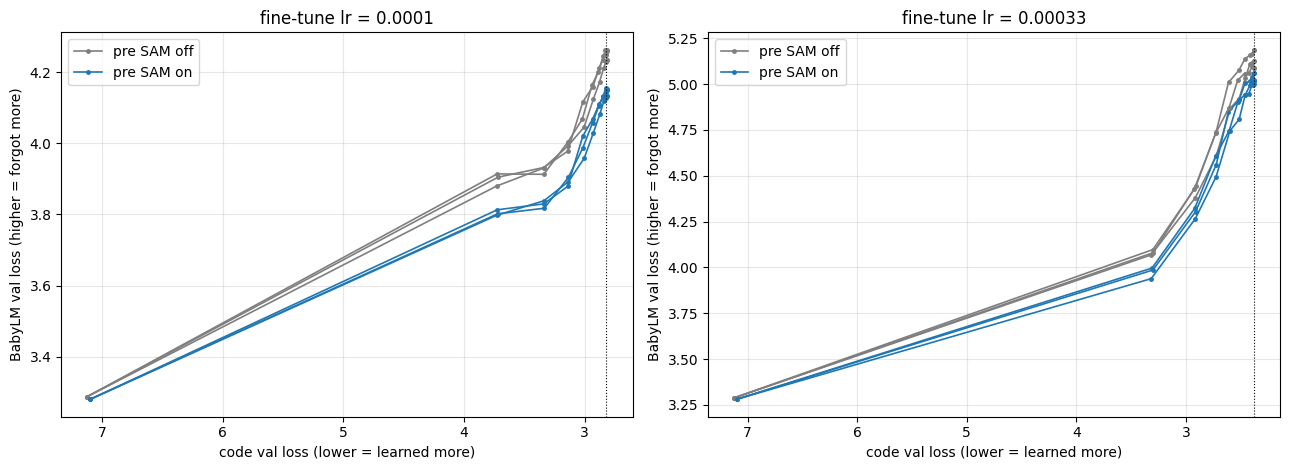

저장: /kaggle/working/exp_llm_adamw


In [8]:
# ============ 셀 8: 결과 정리 ============
import matplotlib.pyplot as plt
df = pd.DataFrame(ROWS)

def baby_at(curve, target):
    """코드 loss가 target까지 내려간 지점의 BabyLM loss (선형 보간)"""
    for a, b in zip(curve, curve[1:]):
        if b['code'] <= target:
            t = 1.0 if a['code'] == b['code'] else min(max((a['code'] - target) / (a['code'] - b['code']), 0), 1)
            return a['baby'] + t * (b['baby'] - a['baby'])
    return float('nan')

df['matched_forgetting'] = np.nan
TARGETS = {}
for lr in FT_LRS:
    sub = df[np.isclose(df.lr, lr)]
    target = max(min(p['code'] for p in CURVES[f'{r.lr}|{r.seed}|{r.pre}']) for r in sub.itertuples())
    TARGETS[lr] = target
    for i, r in sub.iterrows():
        df.loc[i, 'matched_forgetting'] = baby_at(CURVES[f'{r.lr}|{r.seed}|{r.pre}'], target) - r.baby_before
df.to_csv(f'{OUT}/ft_results_final.csv', index=False)

print('===== 1. 평균 =====')
display(df.groupby(['lr', 'pre'])[['code_after', 'baby_before', 'baby_after', 'forgetting',
                                    'matched_forgetting', 'delta_rel']].mean().round(4))

print('\n===== 2. 핵심: 같은 seed끼리 짝지은 차이 (양수 = 사전학습 decay-SAM이 덜 잊음) =====')
PAIR = []
for lr in FT_LRS:
    a = df[np.isclose(df.lr, lr) & (df.pre == 'pre_off')].set_index('seed').sort_index()
    b = df[np.isclose(df.lr, lr) & (df.pre == 'pre_sam')].set_index('seed').sort_index()
    print(f'\n[파인튜닝 lr={lr:.2g}]  (같은 코드 loss 기준점 = {TARGETS[lr]:.3f})')
    for metric, name in [('forgetting', '망각 (BabyLM loss 증가)'), ('matched_forgetting', '같은 코드 loss 지점 망각'),
                         ('code_after', '코드 loss (새 태스크)')]:
        d = a[metric] - b[metric]
        print(f'  {name:22s}: 평균 {d.mean():+.4f}  (std {d.std():.4f})  seed별 {[round(x, 4) for x in d]}  양수 {int((d > 0).sum())}/{len(d)}')
        PAIR.append(dict(lr=lr, metric=metric, mean=d.mean(), std=d.std(), values=list(d)))
    r_f = b.forgetting.mean() / a.forgetting.mean()
    r_m = b.matched_forgetting.mean() / a.matched_forgetting.mean()
    print(f'  상대 크기 (pre_sam 망각 ÷ pre_off 망각): 최종 {r_f:.3f}  |  같은 지점 {r_m:.3f}   ← 1보다 작을수록 효과 큼')
json.dump(dict(pretrain=PRE, best_lr=BEST_LR, paired=PAIR), open(f'{OUT}/summary.json', 'w'), indent=2, default=float)

fig, axes = plt.subplots(1, len(FT_LRS), figsize=(6.5 * len(FT_LRS), 4.8))
for ax, lr in zip(np.atleast_1d(axes), FT_LRS):
    for s in CFG['ft_seeds']:
        for pre, c in [('pre_off', 'tab:gray'), ('pre_sam', 'tab:blue')]:
            cv = CURVES[f'{lr}|{s}|{pre}']
            ax.plot([p['code'] for p in cv], [p['baby'] for p in cv], color=c, marker='o', ms=2.5, lw=1.2,
                    label=f'{"pre SAM on" if pre == "pre_sam" else "pre SAM off"}' if s == CFG['ft_seeds'][0] else None)
    ax.axvline(TARGETS[lr], color='k', ls=':', lw=0.8)
    ax.invert_xaxis()
    ax.set_xlabel('code val loss (lower = learned more)'); ax.set_ylabel('BabyLM val loss (higher = forgot more)')
    ax.set_title(f'fine-tune lr = {lr:.2g}'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/forgetting_llm.png', dpi=150); plt.show()
print('저장:', OUT)